In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cloud_server_resource_consumption_dataset.csv")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(df.shape)
print(df.head())

(10000, 25)
   hour_of_day  day_of_week  is_weekend  is_peak_hour  active_users  \
0            6            0           0             0          3040   
1           19            1           0             1          4693   
2           14            5           1             0          1199   
3           10            6           1             0           112   
4            7            1           0             0          4989   

   requests_per_minute  avg_request_size_kb  api_calls_per_minute  \
0          3528.593163            75.849039            786.849818   
1          3758.887203            95.257798           1056.615844   
2          1476.103998            66.247144            383.402379   
3           167.792816            73.781887             33.884015   
4          5010.979711             6.535530           2083.248968   

   db_queries_per_minute  background_jobs_count  ...  network_in_mbps  \
0             406.162846                      2  ...        36.268301   


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour_of_day             10000 non-null  int64  
 1   day_of_week             10000 non-null  int64  
 2   is_weekend              10000 non-null  int64  
 3   is_peak_hour            10000 non-null  int64  
 4   active_users            10000 non-null  int64  
 5   requests_per_minute     10000 non-null  float64
 6   avg_request_size_kb     10000 non-null  float64
 7   api_calls_per_minute    10000 non-null  float64
 8   db_queries_per_minute   10000 non-null  float64
 9   background_jobs_count   10000 non-null  int64  
 10  cache_hit_ratio         10000 non-null  float64
 11  allocated_cpu_cores     10000 non-null  int64  
 12  allocated_memory_gb     10000 non-null  float64
 13  container_count         10000 non-null  int64  
 14  running_services_count  10000 non-null 

In [6]:
print(df.describe())

        hour_of_day   day_of_week    is_weekend  is_peak_hour  active_users  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      11.609800      3.006200      0.286500      0.255100   2510.938900   
std        6.951257      2.011459      0.452148      0.435939   1423.520326   
min        0.000000      0.000000      0.000000      0.000000     50.000000   
25%        6.000000      1.000000      0.000000      0.000000   1287.750000   
50%       12.000000      3.000000      0.000000      0.000000   2499.000000   
75%       18.000000      5.000000      1.000000      1.000000   3716.000000   
max       23.000000      6.000000      1.000000      1.000000   4999.000000   

       requests_per_minute  avg_request_size_kb  api_calls_per_minute  \
count         10000.000000         10000.000000          10000.000000   
mean           2894.606015            62.024733           1163.109330   
std            1735.698535            33.174537            803.195262

In [7]:
correlation = df.corr(numeric_only=True)
print(correlation["cpu_usage_percent"].sort_values(ascending=False))

cpu_usage_percent         1.000000
requests_per_minute       0.919786
active_users              0.899578
network_in_mbps           0.859785
network_out_mbps          0.844930
api_calls_per_minute      0.802896
avg_response_time_ms      0.798162
db_queries_per_minute     0.771569
disk_read_ops             0.692226
disk_write_ops            0.650383
memory_usage_percent      0.291561
background_jobs_count     0.085877
is_peak_hour              0.081923
scheduled_job_flag        0.069398
error_rate_percent        0.064238
hour_of_day               0.049134
avg_request_size_kb      -0.001616
container_count          -0.003447
allocated_cpu_cores      -0.006298
allocated_memory_gb      -0.006767
cache_hit_ratio          -0.007733
is_weekend               -0.008449
running_services_count   -0.011355
release_day_flag         -0.015116
day_of_week              -0.015293
Name: cpu_usage_percent, dtype: float64


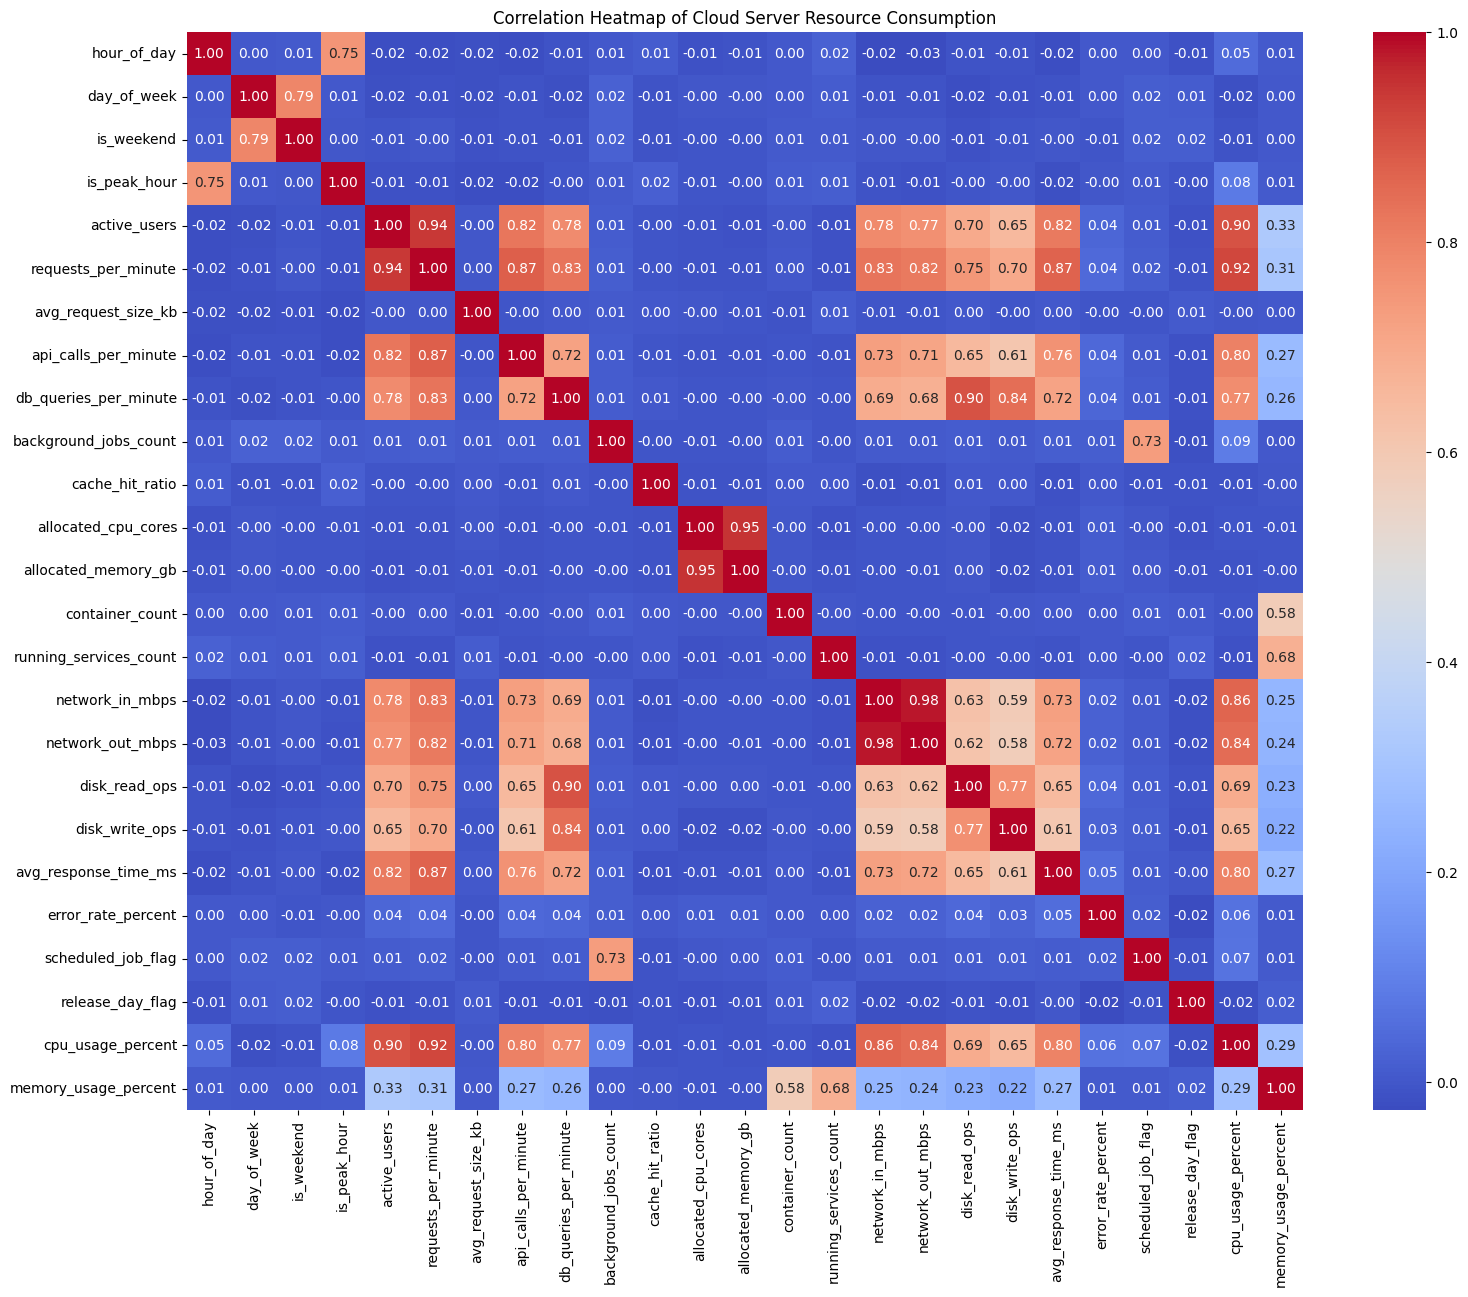

In [8]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Cloud Server Resource Consumption")
plt.show()

In [9]:
target = "cpu_usage_percent"
corr_target = correlation[target].drop(target)
print("Correlation with CPU Usage:")
print(corr_target.sort_values(ascending=False))

Correlation with CPU Usage:
requests_per_minute       0.919786
active_users              0.899578
network_in_mbps           0.859785
network_out_mbps          0.844930
api_calls_per_minute      0.802896
avg_response_time_ms      0.798162
db_queries_per_minute     0.771569
disk_read_ops             0.692226
disk_write_ops            0.650383
memory_usage_percent      0.291561
background_jobs_count     0.085877
is_peak_hour              0.081923
scheduled_job_flag        0.069398
error_rate_percent        0.064238
hour_of_day               0.049134
avg_request_size_kb      -0.001616
container_count          -0.003447
allocated_cpu_cores      -0.006298
allocated_memory_gb      -0.006767
cache_hit_ratio          -0.007733
is_weekend               -0.008449
running_services_count   -0.011355
release_day_flag         -0.015116
day_of_week              -0.015293
Name: cpu_usage_percent, dtype: float64


In [10]:
selected_features = corr_target[corr_target.abs() >= 0.5].index.tolist()
print("Selected Features:")
print(selected_features)

Selected Features:
['active_users', 'requests_per_minute', 'api_calls_per_minute', 'db_queries_per_minute', 'network_in_mbps', 'network_out_mbps', 'disk_read_ops', 'disk_write_ops', 'avg_response_time_ms']


In [11]:
selected_corr = corr_target[corr_target.abs() >= 0.5].sort_values(ascending=False)
print("Selected Features and Correlation:")
print(selected_corr)

Selected Features and Correlation:
requests_per_minute      0.919786
active_users             0.899578
network_in_mbps          0.859785
network_out_mbps         0.844930
api_calls_per_minute     0.802896
avg_response_time_ms     0.798162
db_queries_per_minute    0.771569
disk_read_ops            0.692226
disk_write_ops           0.650383
Name: cpu_usage_percent, dtype: float64


In [12]:
X = df.drop('cpu_usage_percent', axis=1)
y = df['cpu_usage_percent']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [16]:
X_train_scaled
X_test_scaled

array([[ 1.06217649, -1.49644539, -0.63619258, ..., -0.41077525,
        -0.22790242, -1.83470853],
       [-0.95074681,  1.48229637,  1.57185109, ..., -0.41077525,
        -0.22790242, -0.46935381],
       [-1.52586775, -0.50353147, -0.63619258, ...,  2.43442127,
        -0.22790242,  1.20416284],
       ...,
       [ 0.34327531, -0.99998843, -0.63619258, ..., -0.41077525,
        -0.22790242, -0.18922583],
       [-0.37562586, -0.00707451, -0.63619258, ..., -0.41077525,
        -0.22790242,  1.17837834],
       [-0.08806539, -0.99998843, -0.63619258, ..., -0.41077525,
        -0.22790242, -0.07549541]], shape=(2000, 24))

In [17]:
#linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 6.8771739103994225
RMSE: 8.865437787994644
R2 Score: 0.8984390220059941


In [18]:
#multiple linear regression
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
r2_mlr = r2_score(y_test, y_pred_mlr)
print("Multiple Linear Regression")
print("MAE:", mae_mlr)
print("RMSE:", rmse_mlr)
print("R2 Score:", r2_mlr)

Multiple Linear Regression
MAE: 6.8771739103994225
RMSE: 8.865437787994644
R2 Score: 0.8984390220059941


In [19]:
from sklearn.tree import DecisionTreeRegressor

In [20]:
#decision tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree Regression")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Regression
MAE: 4.823257072523271
MSE: 47.74192916714342
RMSE: 6.909553470894007
R2 Score: 0.9383083387339469


In [21]:
#Random forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regression")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression
MAE: 3.388174680456139
MSE: 22.38070368518703
RMSE: 4.730824841947441
R2 Score: 0.9710798701533686


In [22]:
!pip install xgboost

In [23]:
#xgbooster regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100,random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost Regressor")
print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost Regressor
MAE: 3.6216143806414545
MSE: 24.28149598210604
RMSE: 4.927625795665296
R2 Score: 0.9686236846459059


In [24]:
#GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=100,random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
print("Gradient Boosting Regressor")
print("MAE:", mae_gbr)
print("MSE:", mse_gbr)
print("RMSE:", rmse_gbr)
print("R2 Score:", r2_gbr)

Gradient Boosting Regressor
MAE: 3.4809155409225605
MSE: 21.93082731629045
RMSE: 4.68303612160855
R2 Score: 0.9716611960663707


In [25]:
#Knn regressor
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print("KNN Regressor")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

KNN Regressor
MAE: 5.851929185174748
MSE: 63.01076353840778
RMSE: 7.937931943422529
R2 Score: 0.9185780979499658


In [26]:
X = df.drop('cpu_usage_percent', axis=1)
y = df['cpu_usage_percent']

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [41]:
#Different Gradient Boosting parameter values were defined to find the best-performing model.
param_dist = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    scoring='neg_mean_absolute_error',
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [31]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
#The parameter combination giving the lowest cross-validation MAE was selected as the best configuration.
best_params = random_search.best_params_
best_score = -random_search.best_score_
print("Best Hyperparameters:", best_params)
print("Best MAE:", best_score)

Best Hyperparameters: {'n_estimators': np.int64(100), 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.05}
Best MAE: 3.3895770622752206


In [43]:
#The Gradient Boosting model was trained using the selected best hyperparameters.
gradient_boosting = random_search.best_estimator_
print("Best Gradient Boosting Model:")
print(gradient_boosting)

Best Gradient Boosting Model:
GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=2,
                          n_estimators=np.int64(100), random_state=42)


In [35]:
y_pred = gradient_boosting.predict(X_test)

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
# Defining the parameter grid
param_dist = {
    'n_estimators': np.arange(100, 301, 50),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Initializing RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    scoring='neg_mean_absolute_error',
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
# Fit the model
random_search.fit(X_train, y_train)
# Best parameters and best score
best_params = random_search.best_params_
best_score = -random_search.best_score_
print("Best Parameters:", best_params)
print("Best MAE:", best_score)
#MAE shows the average absolute difference between the actual and predicted CPU usage values; lower values indicate better performance.
#MSE: MSE measures the squared prediction errors, giving more importance to larger errors; lower values indicate better performance.
#RMSE: RMSE represents the typical prediction error in CPU usage units; lower values indicate better model performance.
#R² Score: R² shows how well the model explains the variation in CPU usage; a value closer to 1 indicates better performance.

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': np.int64(100), 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.05}
Best MAE: 3.3895770622752206


In [39]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training the model with best parameters
final_model = GradientBoostingRegressor(
    n_estimators=250,
    min_samples_split=5,
    min_samples_leaf=4,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
final_model.fit(X_train, y_train)

# Predicting on the test set
final_y_pred = final_model.predict(X_test)

# Evaluating the model
final_mae = mean_absolute_error(y_test, final_y_pred)
final_mse = mean_squared_error(y_test, final_y_pred)
final_rmse = final_mse ** 0.5
final_r2 = r2_score(y_test, final_y_pred)

# Displaying the metrics
print(f"Final MAE: {final_mae}")
print(f"Final MSE: {final_mse}")
print(f"Final RMSE: {final_rmse}")
print(f"Final R²: {final_r2}")

Final MAE: 3.368804374614138
Final MSE: 21.405392169702434
Final RMSE: 4.626596175343428
Final R²: 0.9723401583045137


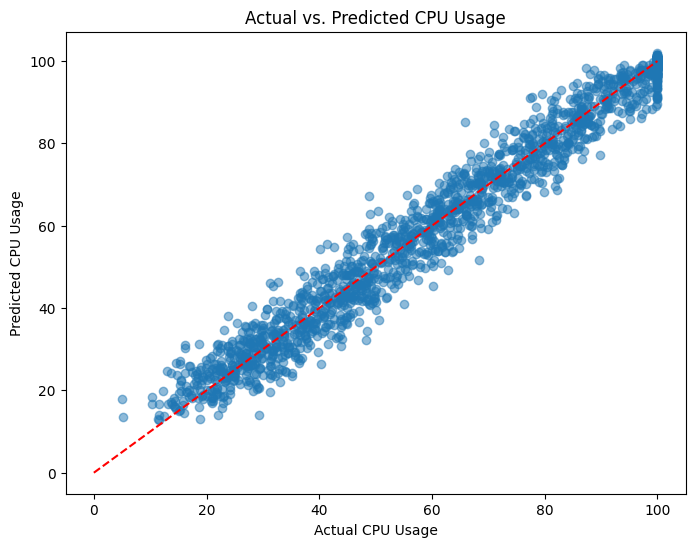

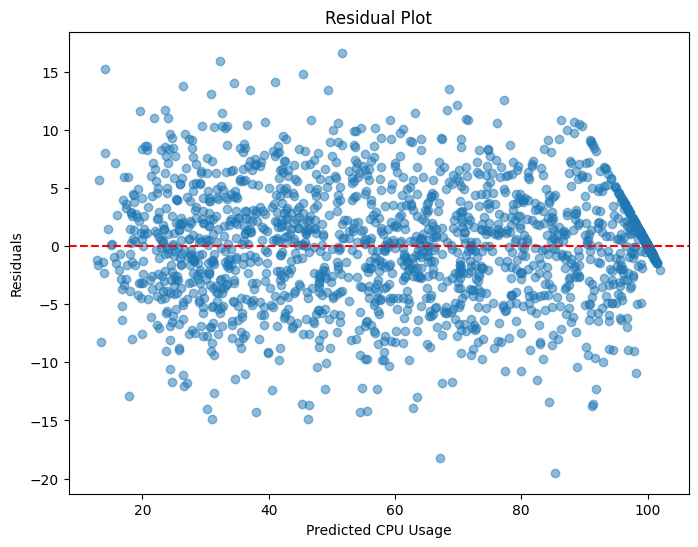

In [48]:
#Actual vs Predicted Plot: The plot compares actual and predicted CPU usage, where points closer to the diagonal line indicate more accurate predictions.
#Residual Plot: The residual plot shows prediction errors; residuals randomly distributed around zero indicate a good model fit.
import matplotlib.pyplot as plt

# Actual vs. Predicted CPU Usage
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_y_pred, alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual CPU Usage")
plt.ylabel("Predicted CPU Usage")
plt.title("Actual vs. Predicted CPU Usage")
plt.show()

# Residual Plot
residuals = y_test - final_y_pred
plt.figure(figsize=(8, 6))
plt.scatter(final_y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted CPU Usage")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()